DayChallenge

        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1          SC1   NaN     1.0  

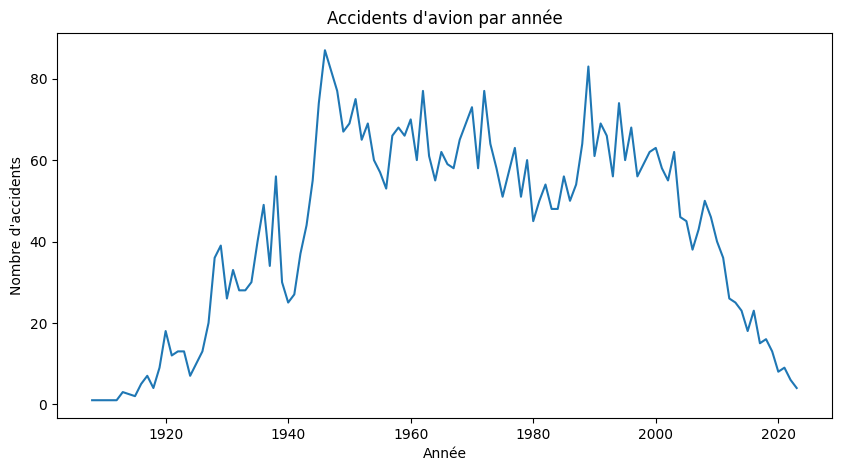

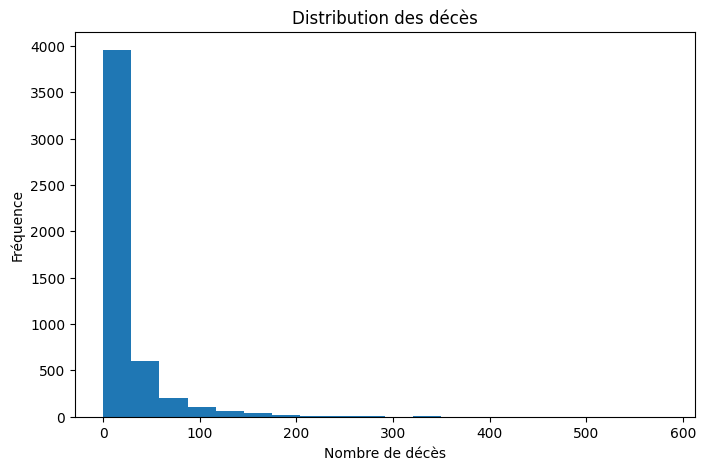

Analyse terminée.


In [ ]:
# =========================
# IMPORTATION DES LIBRAIRIES
# =========================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
# =========================
# CHARGER LE DATASET
# =========================
df = pd.read_csv(
    "Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1"
)
# Afficher les premières lignes
print(df.head())
# =========================
# INFORMATIONS GÉNÉRALES
# =========================
print(df.info())
# =========================
# NETTOYAGE DES DONNÉES
# =========================
# Supprimer les valeurs manquantes importantes
df = df.dropna(subset=["Fatalities"])
# Remplacer les autres valeurs manquantes
df = df.fillna(0)
# Convertir la date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
# Créer une colonne année
df["Year"] = df["Date"].dt.year
# =========================
# ANALYSE EXPLORATOIRE
# =========================
# Nombre total d'accidents
print("Nombre total d'accidents :", len(df))
# Statistiques des décès
print(df["Fatalities"].describe())
# Moyenne
print("Moyenne des décès :", df["Fatalities"].mean())
# Médiane
print("Médiane des décès :", df["Fatalities"].median())
# Écart type
print("Écart type :", df["Fatalities"].std())
# =========================
# ACCIDENTS PAR ANNÉE
# =========================
accidents_per_year = df.groupby("Year").size()
print(accidents_per_year)
# =========================
# TEST STATISTIQUE (T-TEST)
# =========================
# Comparer avant et après 2000
before_2000 = df[df["Year"] < 2000]["Fatalities"]
after_2000 = df[df["Year"] >= 2000]["Fatalities"]
t_stat, p_value = stats.ttest_ind(before_2000, after_2000)
print("T-statistique :", t_stat)
print("P-value :", p_value)
# =========================
# VISUALISATIONS
# =========================
# Graphique des accidents par année
plt.figure(figsize=(10,5))
accidents_per_year.plot()
plt.title("Accidents d'avion par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.show()
# Histogramme des décès
plt.figure(figsize=(8,5))
plt.hist(df["Fatalities"], bins=20)
plt.title("Distribution des décès")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")
plt.show()
# =========================
# CONCLUSION
# =========================
print("Analyse terminée.")